<font size="10" color="DarkSlateGray"><b>The Perceptron from Scratch in Python</b></font>

<img src="https://drive.google.com/uc?export=view&id=1u71bvuqnuzD8EgT6Jqq6frWwM7W1PnHP" width="1000">

In [1]:
from IPython.display import clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os

!wget -q https://gist.githubusercontent.com/wiengel-hm/b4d62137a9e622d8856d2287c74c0808/raw -O calculate_line_points.py
from calculate_line_points import calculate_line_points

In this notebook, we will train a very simple autonomous steering controller using a perceptron, the most basic unit of a neural network.

The dataset was generated in a Gazebo driving simulation while a vehicle was driving around a racetrack. During the drive, we recorded:

* the **cross-track error** → how far the vehicle is away from the road center
* the **heading error** → how much the vehicle is rotated away from the road direction
* the **steering direction** → whether the vehicle steered left or right

The goal is simple:

Given the cross-track and heading error, the controller should predict whether the vehicle should steer left or right to stay on the road.

Before getting started, download the dataset [`sim_steering_data.csv`](https://drive.google.com/file/d/1GJ_8nWeMUwvH5J-DFfOoJ60HgGtc78_8/view?usp=drive_link) and place it into:

`00_Workspace/data/sim_steering_data.csv`


## Connections

In [2]:
import os
from google.colab import drive, userdata
from pathlib import Path

**Connect to Google Drive**

In [3]:
# Connect to Google Drive
if not Path("/content/drive").exists():
  drive.mount("/content/drive")

# Update 'base_dir' with the path to your private workspace on Google Drive
base_dir = Path("/content/drive/MyDrive/00_Workspace")

if not base_dir.exists():
  raise FileNotFoundError(f"Base directory {base_dir} does not exist")

Mounted at /content/drive


## Helper Functions

In [4]:
def plot_loss_surface(all_pts, y, loss_fun):

  # Define weight ranges
  w_vals = np.linspace(-60, 60, 100)
  W1, W2 = np.meshgrid(w_vals, w_vals)
  W_flat = np.stack([W1.ravel(), W2.ravel(), np.zeros(W1.size)], axis=1)  # shape (N, 3)

  # Compute losses for each weight pair
  losses = np.array([loss_fun(all_pts, w[:, None], y) for w in W_flat])
  Loss_surface = losses.reshape(W1.shape)

  # Find and print the minimum
  min_idx = np.argmin(losses)
  min_w = W_flat[min_idx]
  print(f"Minimum loss at weights: w1 = {min_w[0]:.4f}, w2 = {min_w[1]:.4f}, bias = {min_w[2]:.4f}")

  # --- Plot 3D surface ---
  fig = go.Figure()
  fig.add_trace(go.Surface(z=Loss_surface, x=W1, y=W2, colorscale='Spectral', name='Loss Surface'))

  fig.add_trace(go.Surface(
      z=Loss_surface,
      x=W1,
      y=W2,
      colorscale='RdBu',
      showscale=True,
      opacity=0.98,
      contours=dict(
          z=dict(
              show=True,
              usecolormap=True,
              highlight=True,
              project_z=False,
              start=np.min(Loss_surface),
              end=np.max(Loss_surface),
              size=(np.max(Loss_surface) - np.min(Loss_surface)) / 20
          )
      )
  ))

  fig.update_layout(
      title='Cross-Entropy Loss Surface (bias = 0)',
      scene=dict(
          xaxis_title='w1',
          yaxis_title='w2',
          zaxis_title='Loss'
      ),
      autosize=True
  )

  fig.show()


def plot_history(training_history):
  # Create a figure and axis
  fig, ax1 = plt.subplots()

  # Plot the loss on the primary y-axis (left side)
  ax1.plot(training_history[0], label='Loss (Cross-Entropy)')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.tick_params(axis='y')  # Change tick color to match loss

  # Create a second y-axis for accuracy
  ax2 = ax1.twinx()
  ax2.plot(training_history[1], c = 'y')
  ax2.set_ylabel('Accuracy')
  ax2.tick_params(axis='y')  # Change tick color to match accuracy

  # Title and legend
  plt.title('Training Loss and Accuracy History', fontsize=16, loc='center')

  # Add loss value to the legend (for loss)
  ax1.legend([f'Final Loss: {cross_entropy:.2f}'], loc='lower left', fontsize=12)
  ax2.legend([f'Final Accuracy: {accuracy:.2f}'], loc='lower right', fontsize=12)

  # Add grid for readability
  ax1.grid(True, linestyle='--', alpha=0.7)

  # Show the plot
  plt.show()

def _plot_data(line_parameters = None, data = None):

  # --- Optional: Visualize the Data ---
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(data['cross_track_error_m'], data['heading_error_rad'],
                        c=data['steering_direction'], cmap='coolwarm', alpha=0.7, s=10)

  # Add labels and title with larger font size
  plt.xlabel('x1: Cross-Track Error (y) [m]', fontsize=18)
  plt.ylabel('x2: Heading Error (theta) [rad]', fontsize=18)
  plt.title(f'Steering Angles from ROS Gazebo Simulation', fontsize=22)

  # Add a legend
  handles, _ = scatter.legend_elements()
  plt.legend(handles, ['Steer Right (0)', 'Steer Left (1)'], title="Command")

  # Add grid lines and center axes for clarity
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
  plt.axvline(0, color='black', linewidth=0.5, linestyle='--')


  # Plot line

  if not line_parameters is None:
    w1, w2, b = np.asarray(line_parameters).flatten()
    l1, l2 = calculate_line(w1, w2, b)

    try:
        plt.plot(l1, l2, '-', c='g', linewidth=5, alpha=0.6)  # Plot decision boundary
    except Exception as e:
        print(f"Error while plotting the decision boundary: {e}")


  # Show the plot
  plt.show()

def _plot_decision_boundary(forward_fn, W1, W2, X, y, df):

    x1_data_min = df['cross_track_error_m'].min()
    x1_data_max = df['cross_track_error_m'].max()
    x2_data_min = df['heading_error_rad'].min()
    x2_data_max = df['heading_error_rad'].max()

    xx, yy = np.meshgrid(
        np.linspace(x1_data_min, x1_data_max, 200),
        np.linspace(x2_data_min, x2_data_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Add bias to grid input
    grid_aug = np.hstack([grid, np.ones((grid.shape[0], 1))])

    # Forward pass on the grid
    layer1 = forward(grid_aug, W1)
    Z = forward(layer1, W2).reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#f4cccc', '#c9daf8'], alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor='w', s=20, alpha=0.8)
    plt.title(f"Hidden units: {W1.shape[1]}")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()


## Load Data

In [6]:
csv_filepath = base_dir / 'data' / 'sim_steering_data.csv'

df = pd.read_csv(csv_filepath)

x1_data_min = df['cross_track_error_m'].min()
x1_data_max = df['cross_track_error_m'].max()
x2_data_min = df['heading_error_rad'].min()
x2_data_max = df['heading_error_rad'].max()

calculate_line = lambda w1, w2, b: calculate_line_points(w1, w2, b, x1_data_min, x1_data_max, x2_data_min, x2_data_max)

plot_data = lambda line_parameters=None: _plot_data(line_parameters, df)

df.head()

,cross_track_error_m,heading_error_rad,steering_direction
0,-0.100368,-0.095318,0
1,0.360571,-0.101208,1
2,0.185595,0.162502,1
3,0.078927,-0.100182,0
4,-0.275185,-0.091220,0


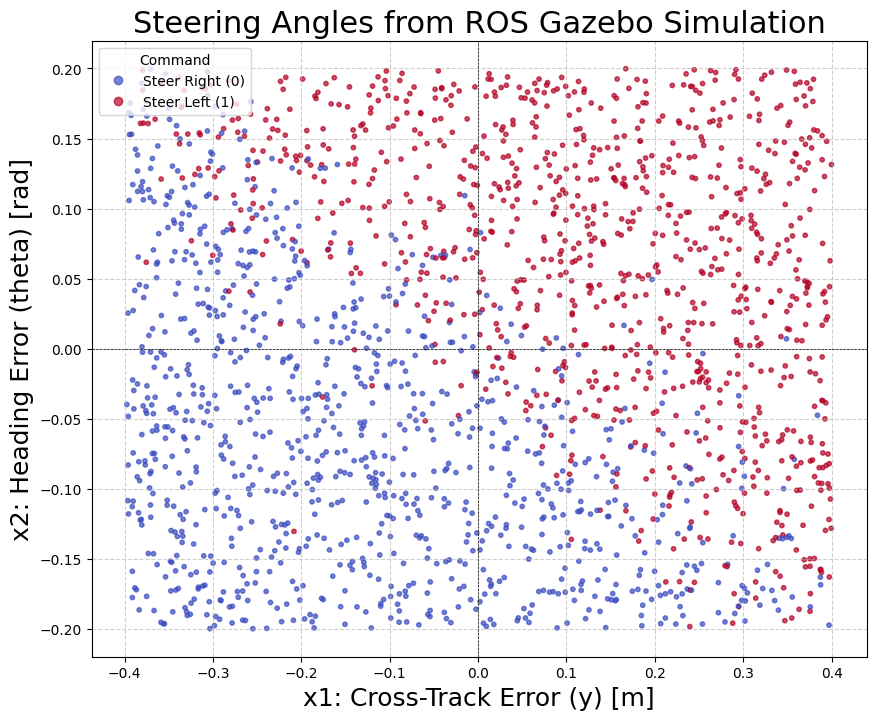

In [7]:
# Plot data
plot_data()

## The Perceptron from Scratch

### Model Initialization

In [ ]:
# Initialize perceptron weights randomly with reproducibility
# Note: If bias is too high, the line might be outside the visible window. [3, 7, 11, 13, 14, 18]

### Activation Functions

### Loss Functions

### Metrics

### Gradient Descent

In [ ]:
x1 = df['cross_track_error_m']
x2 = df['heading_error_rad']
all_pts = np.column_stack([x1, x2, np.ones_like(x1)]) # (M,3)

y = np.expand_dims(df['steering_direction'], axis = 1) # (M,1)

# plot_loss_surface(all_pts, y, calculate_cross_entropy)

Minimum loss at weights: w1 = 15.1515, w2 = 30.9091, bias = 0.0000


### Training

### Breaking Linearity: The Power of Depth and Hidden Units

In [ ]:
# Set fixed values — only W1 and W2 vary for plotting the decision boundary
# plot_decision_boundary = lambda W1, W2: _plot_decision_boundary(forward, W1, W2, all_pts, y, df)

# Hyperparametertuning